In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv("cleaned_ai4i_data.csv")
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0,False,True
1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0,True,False
2,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0,True,False
3,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0,True,False
4,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0,True,False


In [ ]:
df.shape

(10000, 8)

In [ ]:
target = "Machine failure"

In [ ]:
X = df.drop(columns=[target])
y = df[target]

In [ ]:
X.shape, y.shape

((10000, 7), (10000,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
y_train.value_counts(normalize=True)

,proportion
Machine failure,
0,0.966125
1,0.033875


In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr_model.predict(X_test)

In [ ]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_accuracy

0.9675

In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



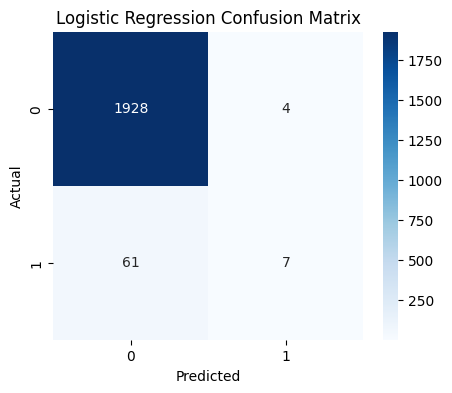

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

In [ ]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_accuracy

0.973

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.77      0.29      0.43        68

    accuracy                           0.97      2000
   macro avg       0.87      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000



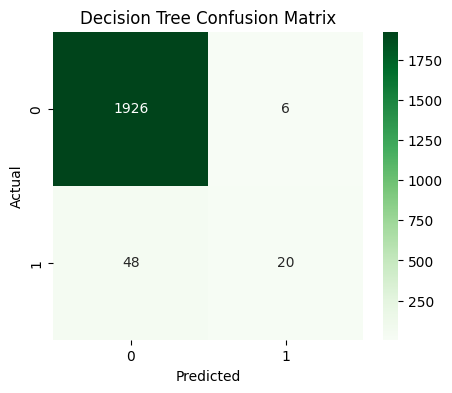

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [lr_accuracy, dt_accuracy]
})

results

,Model,Accuracy
0,Logistic Regression,0.9675
1,Decision Tree,0.9730


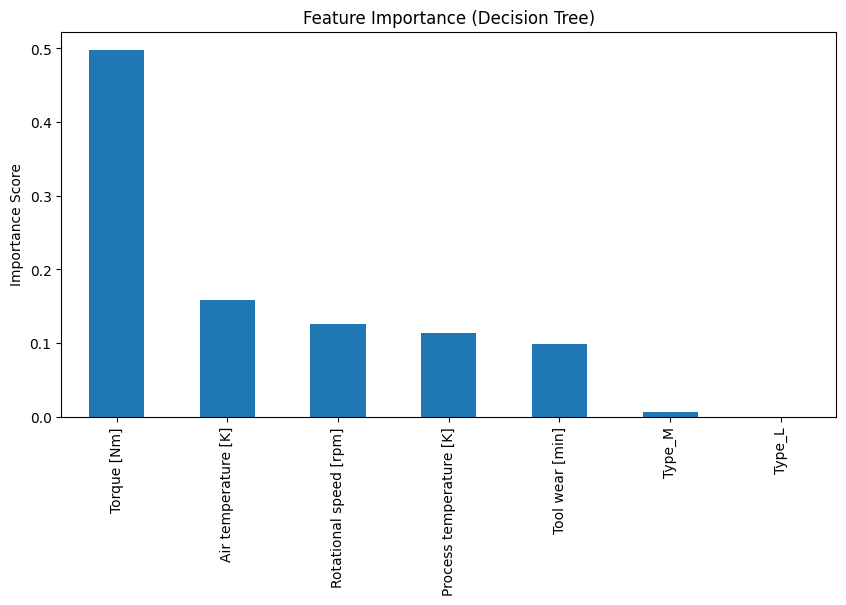

In [ ]:
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,5))
feature_importance.plot(kind='bar')
plt.title("Feature Importance (Decision Tree)")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
joblib.dump(lr_model, "logistic_model.pkl")
joblib.dump(dt_model, "decision_tree_model.pkl")

['decision_tree_model.pkl']

In [ ]:
["logistic_model.pkl", "decision_tree_model.pkl"]

['logistic_model.pkl', 'decision_tree_model.pkl']